In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_feather('merfish.feather')

In [3]:
test = df

In [20]:
test.columns.tolist()

['Cell_ID',
 'Animal_ID',
 'Animal_sex',
 'Behavior',
 'Bregma',
 'Centroid_X',
 'Centroid_Y',
 'Cell_class',
 'Neuron_cluster_ID',
 'Ace2',
 'Adora2a',
 'Aldh1l1',
 'Amigo2',
 'Ano3',
 'Aqp4',
 'Ar',
 'Arhgap36',
 'Avpr1a',
 'Avpr2',
 'Baiap2',
 'Bdnf',
 'Blank_1',
 'Blank_2',
 'Blank_3',
 'Blank_4',
 'Blank_5',
 'Bmp7',
 'Brs3',
 'Calcr',
 'Cbln1',
 'Cbln2',
 'Cckar',
 'Cckbr',
 'Ccnd2',
 'Cd24a',
 'Cdkn1a',
 'Cenpe',
 'Chat',
 'Coch',
 'Col25a1',
 'Cplx3',
 'Cpne5',
 'Creb3l1',
 'Crhbp',
 'Crhr1',
 'Crhr2',
 'Cspg5',
 'Cxcl14',
 'Cyp19a1',
 'Cyp26a1',
 'Cyr61',
 'Dgkk',
 'Ebf3',
 'Egr2',
 'Ermn',
 'Esr1',
 'Etv1',
 'Fbxw13',
 'Fezf1',
 'Fn1',
 'Fst',
 'Gabra1',
 'Gabrg1',
 'Gad1',
 'Galr1',
 'Galr2',
 'Gbx2',
 'Gda',
 'Gem',
 'Gjc3',
 'Glra3',
 'Gpr165',
 'Greb1',
 'Grpr',
 'Htr2c',
 'Igf1r',
 'Igf2r',
 'Irs4',
 'Isl1',
 'Kiss1r',
 'Klf4',
 'Krt90',
 'Lepr',
 'Lmod1',
 'Lpar1',
 'Man1a',
 'Mc4r',
 'Mki67',
 'Mlc1',
 'Myh11',
 'Ndnf',
 'Ndrg1',
 'Necab1',
 'Nos1',
 'Npas1',
 'Npy1r',

In [5]:
test['Npyr'] = test.Npy1r + test.Npy2r
print(test[test.Npyr>0].shape[0]/test.shape[0])

0.6863991562954834


In [6]:
# Percentage of neurons positive for either Y1 or Y2
test_Y = test[((test.Npy1r > 0) | (test.Npy2r > 0))]
percent_Y = test_Y.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are either Y1 or Y2: {percent_Y:.2f}%")

Percentage of neurons that are either Y1 or Y2: 68.64%


In [19]:
# Percentage of neurons positive for Y1 only
test_Y1 = test[((test.Npy1r > 0))]
percent_Y1 = test_Y1.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are Y1: {percent_Y1:.2f}%")

Percentage of neurons that are Y1: 47.99%


In [18]:
# Percentage of neurons positive for Y2 only
test_Y2 = test[((test.Npy2r > 0))]
percent_Y2 = test_Y2.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are Y2: {percent_Y2:.2f}%")

Percentage of neurons that are Y2: 50.85%


In [15]:
# Calculate the percentage of neurons positive for both Esr1 and Npy2r
test_est = test[(test.Esr1 > 0) & (test.Npy2r > 0)]
percent_est = test_est.shape[0] / test.shape[0] * 100
print(f"Percentage of npy2r+ neurons that are also esr1+: {percent_est:.2f}%")

# Calculate the percentage of neurons positive for both Pgr and Npy2r
test_pgr = test[(test.Pgr > 0) & (test.Npy2r > 0)]
percent_pgr = test_pgr.shape[0] / test.shape[0] * 100
print(f"Percentage of npy2r+ neurons that are also pgr+: {percent_pgr:.2f}%")

# Combined calculation for either Esr1 or Pgr positive
test_combined = test[((test.Esr1 > 0) | (test.Pgr > 0)) & (test.Npy2r > 0)]
percent_combined = test_combined.shape[0] / test.shape[0] * 100
print(f"Percentage of npy2r+ neurons that are either esr1+ or pgr+: {percent_combined:.2f}%")


Percentage of npy2r+ neurons that are also esr1+: 18.92%
Percentage of npy2r+ neurons that are also pgr+: 25.14%
Percentage of npy2r+ neurons that are either esr1+ or pgr+: 31.10%


In [10]:
test_hr = test[ (test.Esr1 >0) & (test.Pgr >0) & (test.Cell_class.isin(['Inhibitory']))]
# test_hr = test
test_hr = test_hr.iloc[:, 9:].drop(columns = ['Fos']).dropna()
test_hr['Pgr_esr'] = np.log(test_hr.Pgr / test_hr.Esr1)
test_hr['Npyr'] = test_hr.Npy1r + test_hr.Npy2r
test_hr = test_hr[test_hr.Npyr>0]
test_hr['Gabra1_log'] = np.log(test_hr['Gabra1'])

/Users/caom/Documents/negative_parental_switch/.conda/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


/Users/caom/Documents/negative_parental_switch/.conda/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


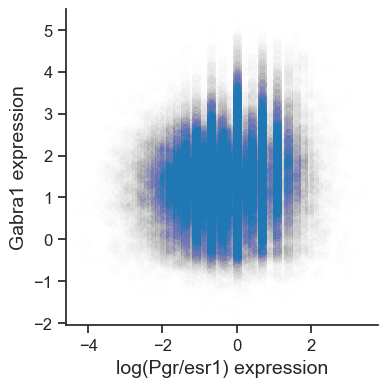

In [11]:
plt.rcParams['figure.figsize'] = 7,5
sns.set_theme(style="ticks")
sns.lmplot(x = 'Pgr_esr', y = 'Gabra1_log' , data = test_hr,scatter_kws={'alpha':0.002, 'color': 'Tab:blue'}, line_kws={'color': 'Tab:blue'},  height=4, aspect=1)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel('log(Pgr/esr1) expression', fontsize = 14)
plt.ylabel('Gabra1 expression', fontsize = 14)      
plt.savefig('output_figures/Gabra1_corr.png',dpi = 300, bbox_inches = 'tight')
plt.show()

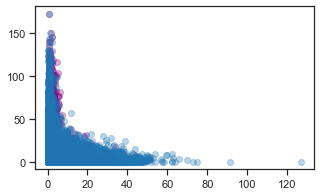

In [8]:
plt.subplots(figsize = (5,3))
plt.scatter(test_hr.Pgr, test_hr.Gabra1 , color = 'purple', alpha = 0.3)
plt.scatter(test_hr.Esr1, test_hr.Gabra1, color = 'Tab:blue', alpha = 0.3)
plt.show()

In [9]:
corr =test_hr.corr().Pgr_esr
display(corr.sort_values())


Esr1         -0.560033
Coch         -0.164719
Scg2         -0.156052
Ar           -0.153568
Ntng1        -0.133731
                ...   
Syt2          0.086817
Gabra1_log    0.114396
Gabra1        0.122658
Pgr           0.264186
Pgr_esr       1.000000
Name: Pgr_esr, Length: 163, dtype: float64

In [10]:
corr =test_hr.corr().Esr1
corr.sort_values()

Pgr_esr      -0.560033
Gabra1_log   -0.183004
Gabra1       -0.179996
Ccnd2        -0.121547
Synpr        -0.107370
                ...   
Coch          0.308312
Scg2          0.345111
Ntng1         0.351045
Pgr           0.446096
Esr1          1.000000
Name: Esr1, Length: 163, dtype: float64